In [1]:
from tkinter import Grid
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


MAX_SAMPLES_DATA = 10000


def reduce_dataset(df: pd.DataFrame) -> pd.DataFrame:
    new_df = df.copy()

    # Add new Rows
    delay_cols = [
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "SECURITY_DELAY",
        "AIRLINE_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "WEATHER_DELAY",
        "AIR_SYSTEM_DELAY",
    ]

    delays = new_df[delay_cols].fillna(0)

    # Ich möchte wissen ob ich meinen Anschluss Flug schaffe ohne zeitlichen Druck
    new_df["DELAY"] = (
        delays["ARRIVAL_DELAY"] > 0
    )

    # Remove not needed Rows
    new_df.drop(columns=["YEAR"], inplace=True)
    new_df.drop(columns=["SCHEDULED_DEPARTURE"], inplace=True)
    new_df.drop(columns=["DEPARTURE_TIME"], inplace=True)
    new_df.drop(columns=["DEPARTURE_DELAY"], inplace=True)
    new_df.drop(columns=["TAXI_OUT"], inplace=True)
    new_df.drop(columns=["TAXI_IN"], inplace=True)
    new_df.drop(columns=["WHEELS_OFF"], inplace=True)
    new_df.drop(columns=["WHEELS_ON"], inplace=True)
    new_df.drop(columns=["ELAPSED_TIME"], inplace=True)
    new_df.drop(columns=["AIR_TIME"], inplace=True)
    new_df.drop(columns=["ARRIVAL_TIME"], inplace=True)
    new_df.drop(columns=["AIRLINE_DELAY"], inplace=True)
    new_df.drop(columns=["LATE_AIRCRAFT_DELAY"], inplace=True)
    new_df.drop(columns=["DIVERTED"], inplace=True)
    new_df.drop(columns=["CANCELLED"], inplace=True)
    new_df.drop(columns=["CANCELLATION_REASON"], inplace=True)
    new_df.drop(columns=["ARRIVAL_DELAY"], inplace=True)
    new_df.drop(columns=["SECURITY_DELAY"], inplace=True)
    new_df.drop(columns=["WEATHER_DELAY"], inplace=True)
    new_df.drop(columns=["AIR_SYSTEM_DELAY"], inplace=True)
    new_df.drop(columns=["SCHEDULED_ARRIVAL"], inplace=True)
    new_df.drop(columns=["DISTANCE"], inplace=True)
    new_df.drop(columns=["SCHEDULED_TIME"], inplace=True)
    new_df.drop(columns=["TAIL_NUMBER"], inplace=True)

    return new_df


def describe_dataset(dataset: pd.DataFrame, path: str):
    print(f"DESCRIBE========={path}")
    print(dataset.describe())
    print("HEAD=========")
    print(dataset.head())
    print("TAIL=========")
    print(dataset.tail())
    print("==============")

def load_dataset(path: str) -> pd.DataFrame:
    dataset = pd.read_csv(path, low_memory=False)
    dataset = reduce_dataset(dataset)
    describe_dataset(dataset, path)
    return dataset


ds_flights = load_dataset("./data/flights.csv")

DESCRIBE=========./data/flights.csv
           MONTH        DAY  DAY_OF_WEEK  FLIGHT_NUMBER
count 5819079.00 5819079.00   5819079.00     5819079.00
mean        6.52      15.70         3.93        2173.09
std         3.41       8.78         1.99        1757.06
min         1.00       1.00         1.00           1.00
25%         4.00       8.00         2.00         730.00
50%         7.00      16.00         4.00        1690.00
75%         9.00      23.00         6.00        3230.00
max        12.00      31.00         7.00        9855.00
HEAD=========
   MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER ORIGIN_AIRPORT  \
0      1    1            4      AS             98            ANC   
1      1    1            4      AA           2336            LAX   
2      1    1            4      US            840            SFO   
3      1    1            4      AA            258            LAX   
4      1    1            4      AS            135            SEA   

  DESTINATION_AIRPORT  DELAY  
0     

### Display the Data in a pairplot to understand it

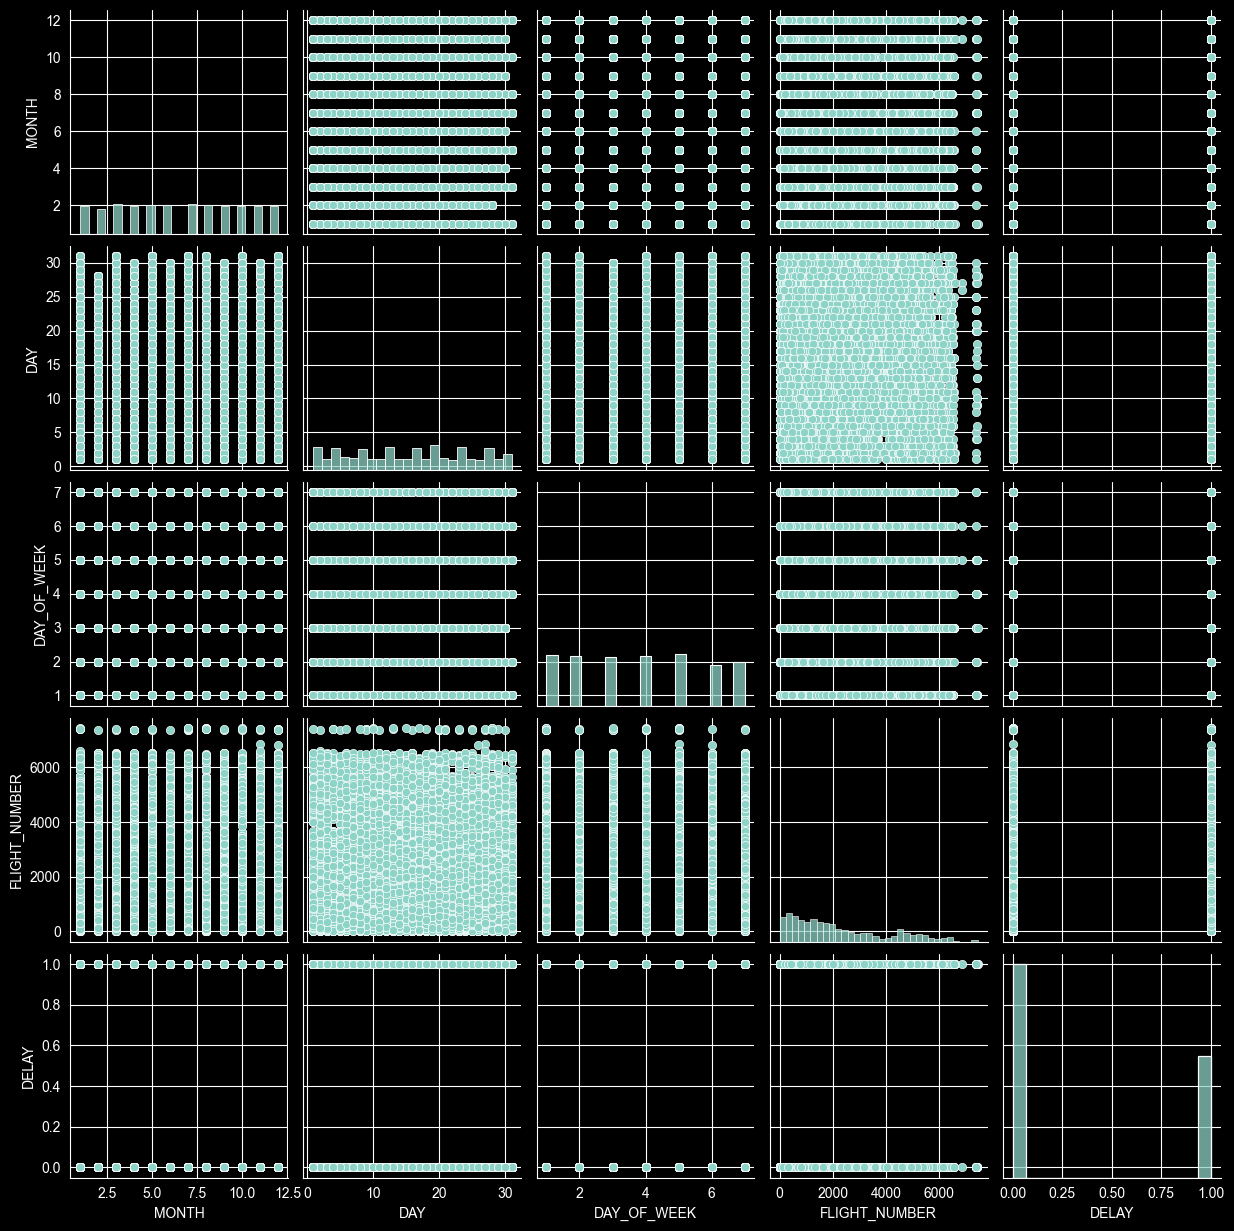

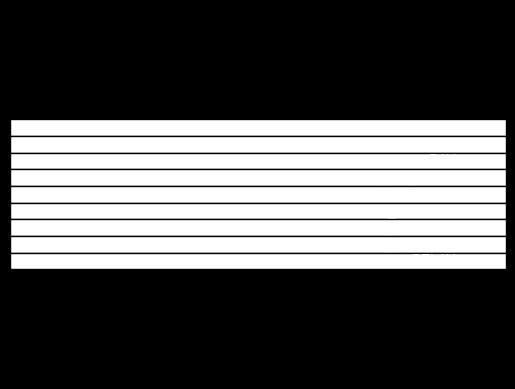

In [2]:
def plot_dataset(dataset: pd.DataFrame) -> None:
    new_df = dataset.copy()

    if MAX_SAMPLES_DATA > 0:
        new_df = new_df.sample(n=MAX_SAMPLES_DATA, random_state=42)

    sns.pairplot(new_df)
    plt.show()

    plt.table(
        cellText=[[col] for col in dataset.columns],
        colLabels=["Columns"],
        loc="center"
    )
    plt.axis("off")
    plt.show()


plot_dataset(ds_flights)

### Train / Test / Split

In [3]:
def tts(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:

    new_df = df.copy().sample(100000, random_state=42)

    Y = new_df['DELAY']
    X = new_df.drop(columns=["DELAY"])

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = tts(ds_flights)

### 1 Train the modell -> Found Accuracy 0.64

In [4]:

def train_decision_tree(X_train, y_train, X_test, y_test):

    categorical_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformer = ColumnTransformer(transformers=[
        ("cat_transformer", categorical_transformer, categorical_cols),
    ])

    preprocess = Pipeline(steps=[
        ("transform", transformer),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('regression', DecisionTreeClassifier())
    ])


    param_grid = {
        "regression__criterion": ["gini", "entropy", "log_loss"],
        "regression__max_depth": [None, 2, 3, 5, 10, 15, 20, 30, 50],
        "regression__min_samples_split": [2,  50],
        "regression__min_samples_leaf": [1, 20],
    }
    gs = GridSearchCV(model, param_grid, cv=2)
    gs.fit(X_train, y_train)
    #model.fit(X_train, y_train)

    print(gs.best_score_)
    print(gs.best_estimator_)

train_decision_tree(X_train, y_train, X_test, y_test)

0.64105
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('transform',
                                  ColumnTransformer(transformers=[('cat_transformer',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['AIRLINE',
                                                                    'ORIGIN_AIRPORT',
                                                                    'DESTINATION_AIRPORT'])])),
                                 ('normalizer', Normalizer())])),
                ('regression',
                 DecisionTr